In [1]:
import uproot, glob
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import os, glob, pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib as mlp
import mplhep as hep
plt.style.use([hep.style.ROOT, hep.style.firamath])
from matplotlib.colors import LinearSegmentedColormap
import scipy
from scipy.stats import norm
# Define the CMS color scheme
cms_colors = [
    (0.00, '#FFFFFF'),  # White
    (0.33, '#005EB8'),  # Blue
    (0.66, '#FFDD00'),  # Yellow
    (1.00, '#FF0000')   # red
]

# Create the CMS colormap
cms_cmap = LinearSegmentedColormap.from_list('CMS', cms_colors)

mkdir -p failed for path /uscms_data/d1/bbbam/.cache/matplotlib: [Errno 30] Read-only file system: '/uscms_data'
Matplotlib created a temporary cache directory at /tmp/matplotlib-f2vjittd because there was an issue with the default path (/uscms_data/d1/bbbam/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# out_dir='data/plot_H_AA_4Tau_M_10_signal_kinematics'
# out_dir='../analysis_run3/AN_Note_Plot/mass_regression_with_map_signal_background_pridiction'
out_dir='../analysis_run3/AN_Note_Plot/stack_plots'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)


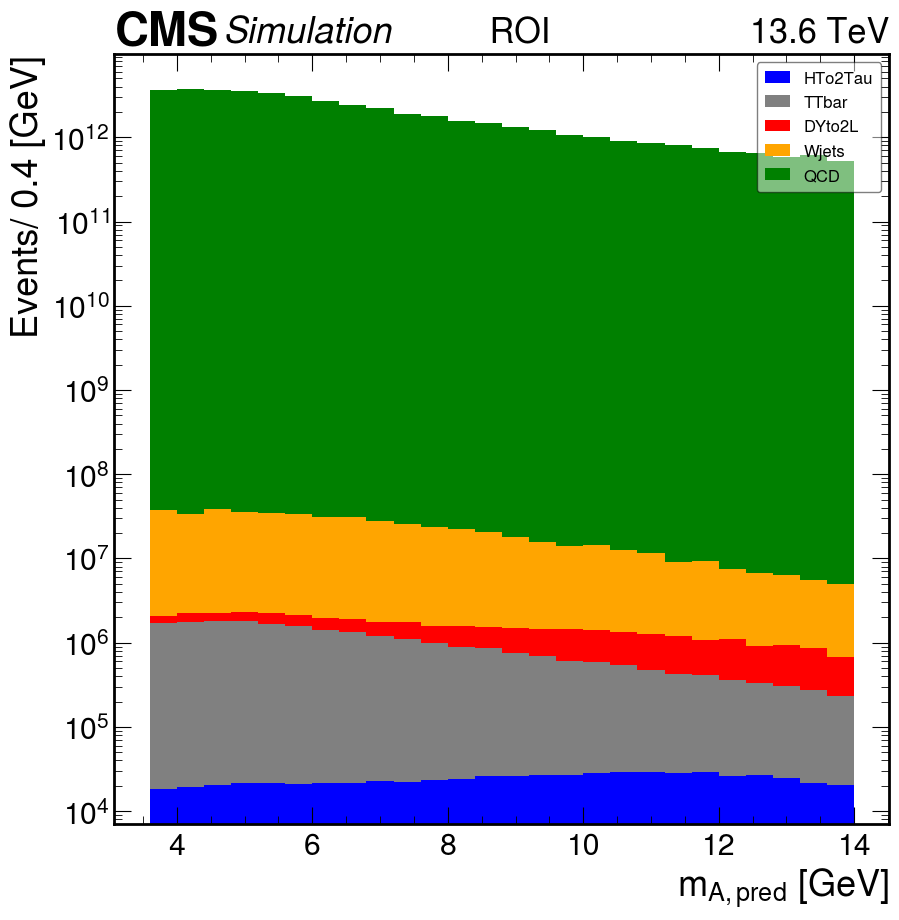

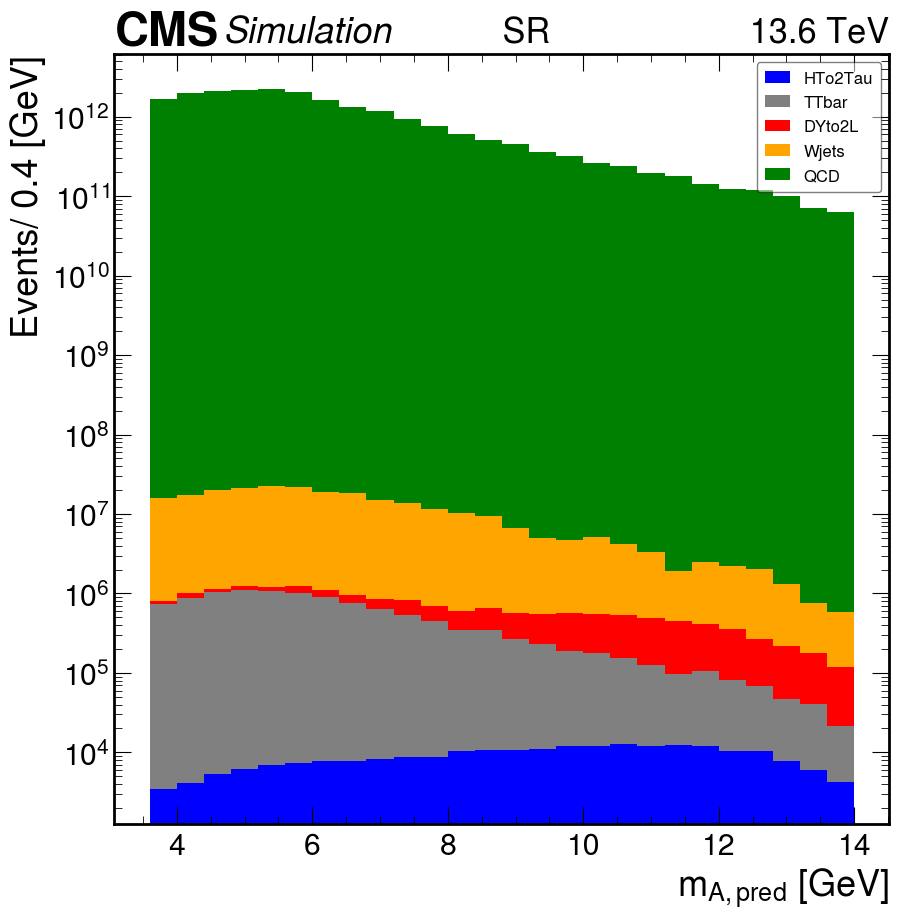

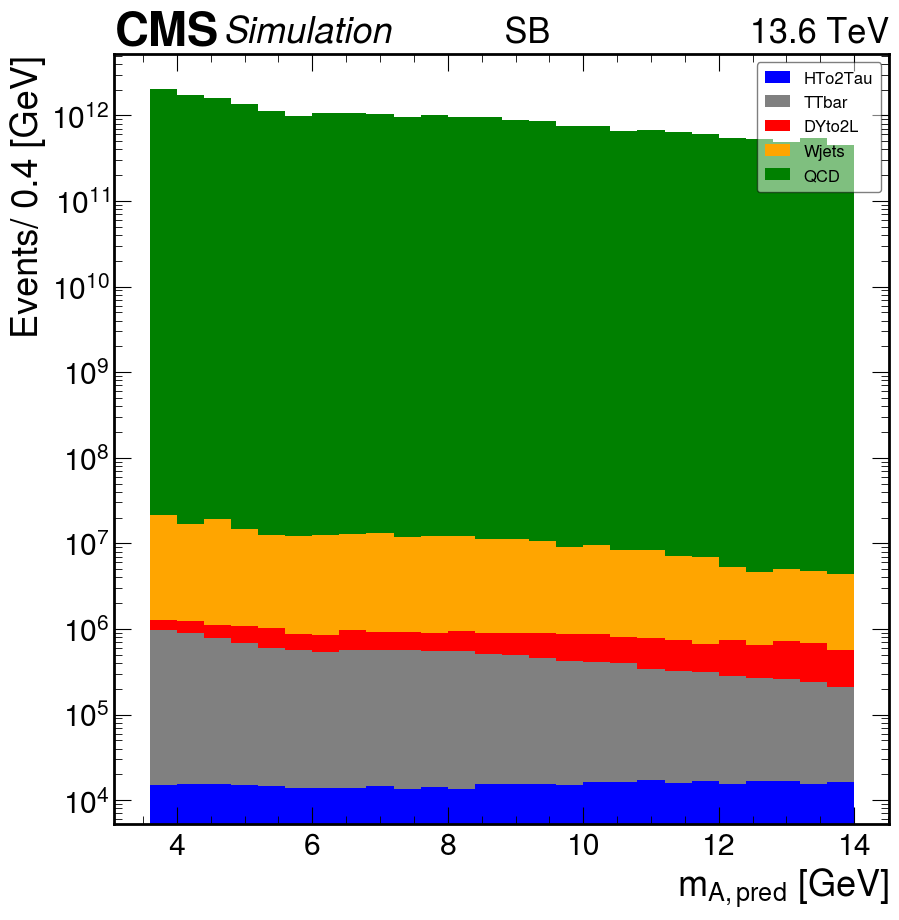

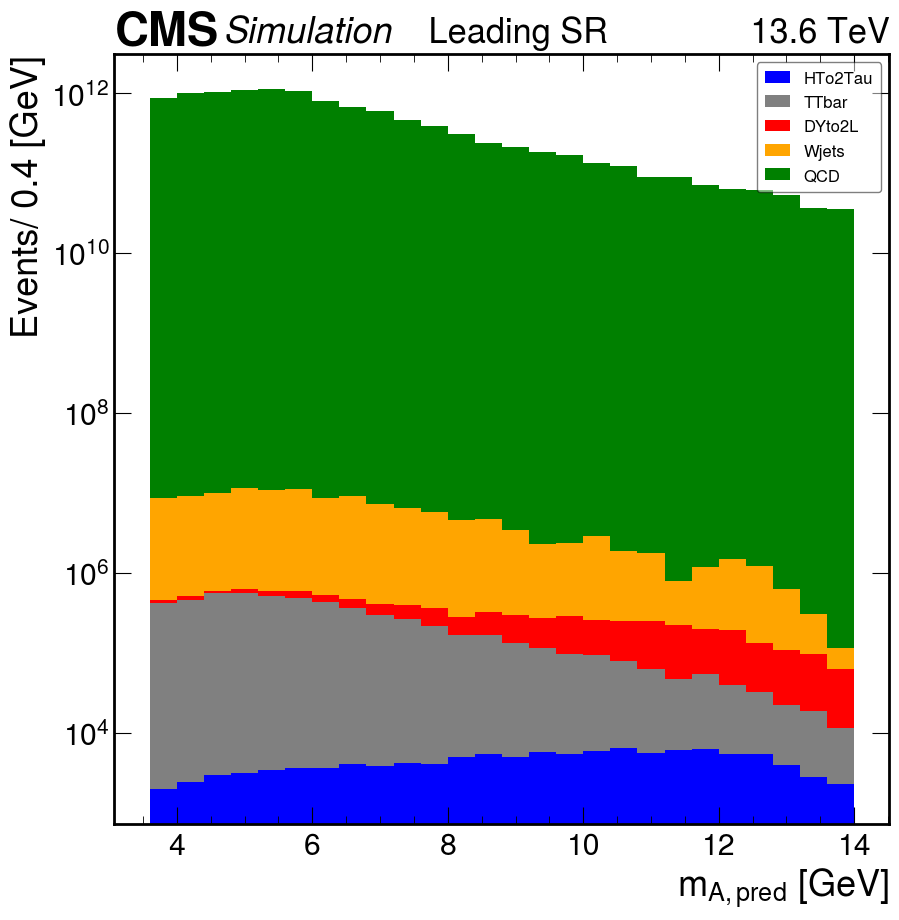

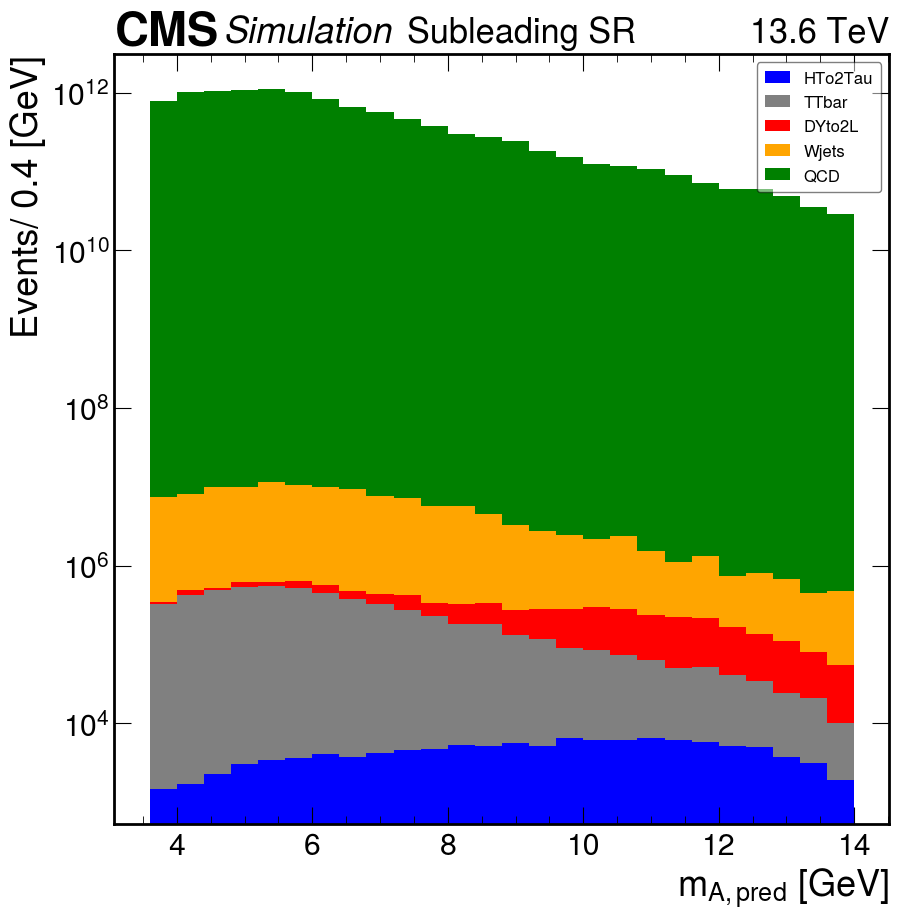

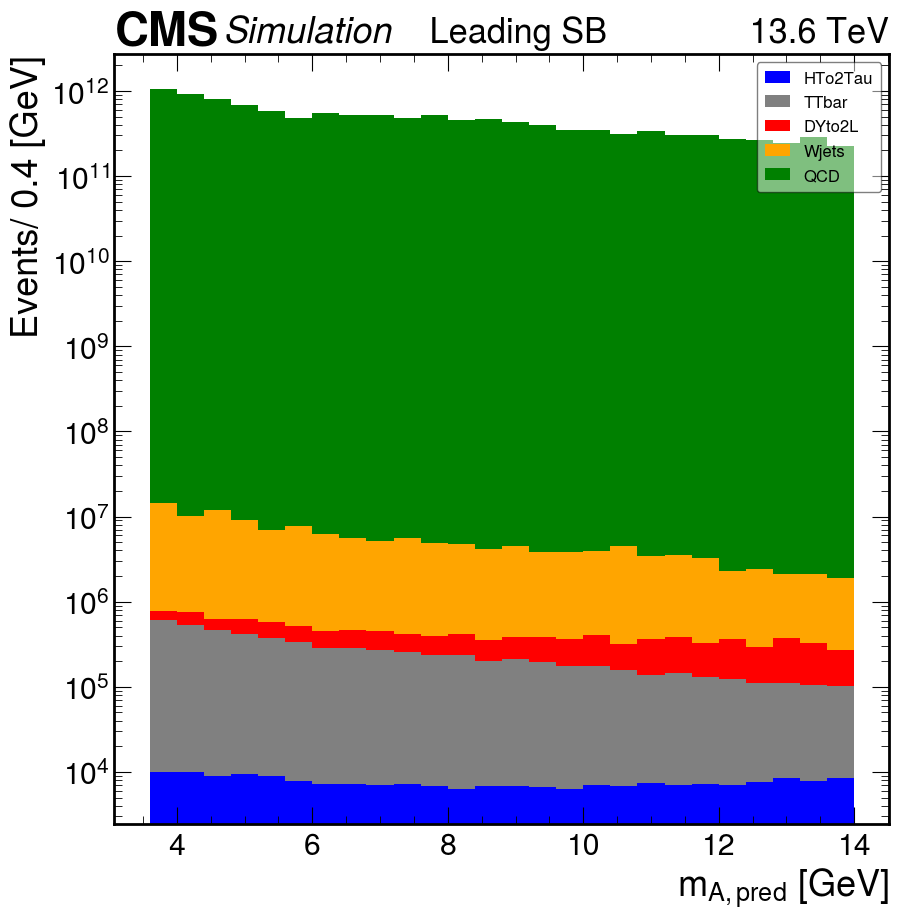

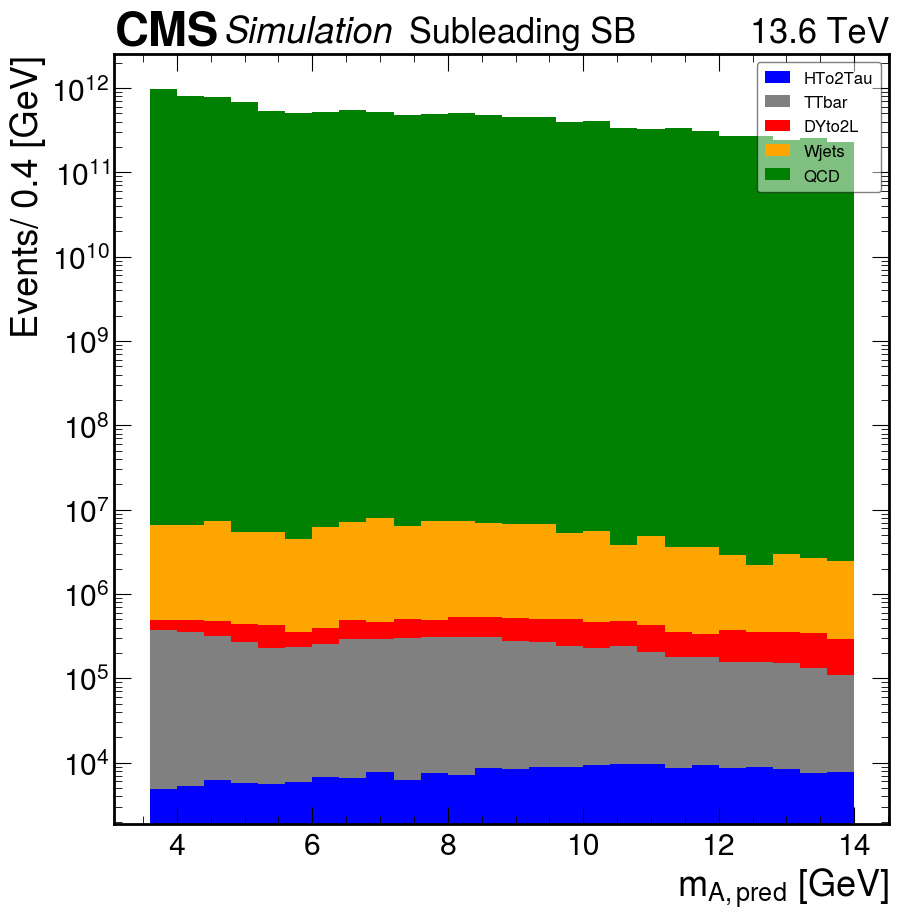

In [13]:
def corrected_pred_mode_miniAOD_5(m):
    mass = m + 0.007372 * m**3 - 0.1353 * m**2 + 0.6927 * m - 2.9
    return mass

# data_files_back = ['QCD_background_11.h5.pkl', 'DYto2L_background_1.h5.pkl',       
#    'HTo2Tau_background_2.h5.pkl',    'TTBar_background_12.h5.pkl', 'WtoLNu_background_1.h5.pkl']

# data_dir ='../analysis_run3/Data_for_plots/ResNet_mapA_signal_backgrounds/'

# back = ['QCD', 'DYTo2Tau', 'HTo2Tau', 'TTBar', 'WToLNu']



sig = ['3.7 GeV ', '4 GeV', '5 GeV', '6 GeV', '8 GeV', '10 GeV', '12 GeV', '14 GeV']
# back = ["DYto2L X 10^5", "HTo2Tau X 10^6", "QCD", "TTbar X 10^5", "Wjets X 10^4"]
back = ["HTo2Tau", "TTbar", "DYto2L", "Wjets", "QCD"]
col_ = ['blue','grey','red','orange', 'green']



data_dir = "../analysis_run3/Data_for_plots/ResNet_mapA_signal_backgrounds_5_ch_inference_miniAOD"


# sig_back = ["3.7 GeV", "4 GeV", "5 GeV", "6 GeV", "8 GeV", "10 GeV", "12 GeV", "14 GeV", "DYto2L", "HTo2Tau", "QCD", "TTbar", "Wjets"]
m_true_mass = [3.7, 4, 5, 6, 8, 10, 12, 14]
data_files_signal = [
    "IMG_signal_mass_3p7_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_4_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_5_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_6_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_8_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_10_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_12_GeV_miniAOD_combined.pkl",
    "IMG_signal_mass_14_GeV_miniAOD_combined.pkl",
]

data_files_back = [ 
    
    "IMG_background_HTo2Tau_miniAOD_combined.pkl",
    "IMG_background_TTbar_miniAOD_combined.pkl",
    "IMG_background_DYto2L_miniAOD_combined.pkl",
    "IMG_background_Wjets_miniAOD_combined.pkl",
    "IMG_background_QCD_miniAOD_combined.pkl",
]


m0_min=3.6
m0_max=14.1
bin_size =0.4
bins = np.arange(m0_min,m0_max,bin_size)

total_background, total_weight = [], []
total_background_sr, total_weight_sr_total = [], []
total_background_sb, total_weight_sb_total = [], []
total_background_leading_sr, total_background_subleading_sr, total_weight_sr = [], [], []
total_background_leading_sb, total_background_subleading_sb, total_weight_sb = [], [], []


luminosity = 181000  # e.g., 137 fb^-1 expressed as 137,000 pb^-1
cross_section = np.array([3.166e1, 7.623e2, 5.453e3, 6.808e4, 1.448e9]) 
total_gen_events = np.array([3e5, 3e5, 4e5, 2.35e5, 2.74e5])
W = cross_section * luminosity / total_gen_events
for i, file_ in enumerate(data_files_back):

    data_file = f"{data_dir}/{file_}"

    with open(data_file, "rb") as infile:
        data = pickle.load(infile)

    m_pred_total = corrected_pred_mode_miniAOD_5(
        data["m_pred"]
    ).flatten()

    jet_pt_total = data["jet_pt"].flatten()

    # ---------------------------------------------------------
    # Make even number of jets
    # ---------------------------------------------------------
    n = len(m_pred_total)
    n_even = n #- (n % 2)

    # reshape into jet pairs (events)
    m_pred = m_pred_total[:n_even].reshape(-1, 2)
    jet_pt = jet_pt_total[:n_even].reshape(-1, 2)

    # ---------------------------------------------------------
    # Leading / subleading jet indices
    # ---------------------------------------------------------
    lead_idx = np.argmax(jet_pt, axis=1)
    sublead_idx = 1 - lead_idx

    # corresponding masses
    m_leading = m_pred[np.arange(len(m_pred)), lead_idx]
    m_subleading = m_pred[np.arange(len(m_pred)), sublead_idx]

    # corresponding pts
    pt_leading = jet_pt[np.arange(len(jet_pt)), lead_idx]
    pt_subleading = jet_pt[np.arange(len(jet_pt)), sublead_idx]

    # ---------------------------------------------------------
    # Event-level mass selection:
    # BOTH jets must satisfy the mass window
    # ---------------------------------------------------------
    mask_pair = (
        (m_leading >= 3.6) &
        (m_leading <= 14) &
        (m_subleading >= 3.6) &
        (m_subleading <= 14)
    )

    m_leading = m_leading[mask_pair]
    m_subleading = m_subleading[mask_pair]

    # ---------------------------------------------------------
    # Save total selected jets
    # ---------------------------------------------------------
    total_background.append(
        np.concatenate([m_leading, m_subleading])
    )

    weights = np.ones(len(m_leading) * 2) * W[i]
    total_weight.append(weights)

    # ---------------------------------------------------------
    # Signal region
    # ---------------------------------------------------------
    sr_mask = np.abs(m_leading - m_subleading) <= 2

    m_leading_sr = m_leading[sr_mask]
    m_subleading_sr = m_subleading[sr_mask]

    weights_sr = np.ones_like(m_leading_sr) * W[i]

    total_background_leading_sr.append(m_leading_sr)
    total_background_subleading_sr.append(m_subleading_sr)
    total_weight_sr.append(weights_sr)

    total_background_sr.append(
        np.concatenate([m_leading_sr, m_subleading_sr])
    )

    weights_sr_total = np.ones(len(m_leading_sr) * 2) * W[i]
    total_weight_sr_total.append(weights_sr_total)

    
    # ---------------------------------------------------------
    # Sideband region
    # ---------------------------------------------------------
    sb_mask = np.abs(m_leading - m_subleading) > 2

    m_leading_sb = m_leading[sb_mask]
    m_subleading_sb = m_subleading[sb_mask]

    weights_sb = np.ones_like(m_leading_sb) * W[i]

    total_background_leading_sb.append(m_leading_sb)
    total_background_subleading_sb.append(m_subleading_sb)
    total_weight_sb.append(weights_sb) 

    total_background_sb.append(
        np.concatenate([m_leading_sb, m_subleading_sb])
    )

    weights_sb_total = np.ones(len(m_leading_sb) * 2) * W[i]
    total_weight_sb_total.append(weights_sb_total)


dpi_=100
save = False
# =========================================================
# Stack histogram
# =========================================================

fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background,
    bins=bins,
    weights=total_weight,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,
)
# plt.yscale('log')
# plt.ylim(1, 1e13)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')

plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f" ROI                     13.6 TeV", loc=0, ax=ax)
ax = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_ROI_normalized_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")


fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_sr,
    bins=bins,
    weights=total_weight_sr_total,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,
)

plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')

plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f" SR                     13.6 TeV", loc=0, ax=ax)
x = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_SR_normalized_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")


fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_sb,
    bins=bins,
    weights=total_weight_sb_total,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,
)

plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')
plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f" SB                     13.6 TeV", loc=0, ax=ax)
x = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_SB_normalized_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")




fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_leading_sr,
    bins=bins,
    weights=total_weight_sr,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,
)
# plt.ylim(0,3000)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')

plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f"     Leading SR               13.6 TeV", loc=0, ax=ax)
x = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_leading_SR_normalized_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")


fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_subleading_sr,
    bins=bins,
    weights=total_weight_sr,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,
)
# plt.ylim(0,3000)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')

plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f"        Subleading SR            13.6 TeV", loc=0, ax=ax)
x = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_subleading_SR_normalized_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")




fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_leading_sb,
    bins=bins,
    weights=total_weight_sb,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,

)
# plt.ylim(0,3500)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')

plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f"     Leading SB               13.6 TeV", loc=0, ax=ax)
x = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_leading_SB_normalized_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")


fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_subleading_sb,
    bins=bins,
    weights=total_weight_sb,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,
)
# plt.ylim(1,1e13)
# plt.yscale('log')
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')

plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f"        Subleading SB            13.6 TeV", loc=0, ax=ax)
x = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_subleading_SB_normalized_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")

ls: cannot access 'out_dir': No such file or directory


In [6]:
# data_dir = "../analysis_run3/Data_for_plots/classifier_and_mass_regression_5_ch_inference_miniAOD"
data_dir = "../analysis_run3/Data_for_plots/classifier_and_mass_regression_5_ch_inference_miniAOD_June_15_2026"

out_dir='../analysis_run3/AN_Note_Plot/stack_plots_after_classifier'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)
# sig_back = ["3.7 GeV", "4 GeV", "5 GeV", "6 GeV", "8 GeV", "10 GeV", "12 GeV", "14 GeV", "DYto2L", "HTo2Tau", "QCD", "TTbar", "Wjets"]
m_true_mass = [3.7, 4, 5, 6, 8, 10, 12, 14]
# data_files_signal = [
#     "IMG_signal_mass_3p7_GeV_miniAOD_combined.pkl",
#     "IMG_signal_mass_4_GeV_miniAOD_combined.pkl",
#     "IMG_signal_mass_5_GeV_miniAOD_combined.pkl",
#     "IMG_signal_mass_6_GeV_miniAOD_combined.pkl",
#     "IMG_signal_mass_8_GeV_miniAOD_combined.pkl",
#     "IMG_signal_mass_10_GeV_miniAOD_combined.pkl",
#     "IMG_signal_mass_12_GeV_miniAOD_combined.pkl",
#     "IMG_signal_mass_14_GeV_miniAOD_combined.pkl",
# ]

# data_files_back = [ 
    
#     "IMG_background_HTo2Tau_miniAOD_combined.pkl",
#     "IMG_background_TTbar_miniAOD_combined.pkl",
#     "IMG_background_DYto2L_miniAOD_combined.pkl",
#     "IMG_background_Wjets_miniAOD_combined.pkl",
#     "IMG_background_QCD_miniAOD_combined.pkl",
# ]

data_files_signal = [
    "IMG_signal_mass_3p7_GeV_miniAOD_combined_seperately_test.pkl",
    "IMG_signal_mass_4_GeV_miniAOD_combined_seperately_test.pkl",
    "IMG_signal_mass_5_GeV_miniAOD_combined_seperately_test.pkl",
    "IMG_signal_mass_6_GeV_miniAOD_combined_seperately_test.pkl",
    "IMG_signal_mass_8_GeV_miniAOD_combined_seperately_test.pkl",
]

data_files_back = [
    "IMG_background_HTo2Tau_miniAOD_combined_seperately_test.pkl",
    "IMG_background_TTbar_miniAOD_combined_seperately_test.pkl",
    "IMG_background_DYto2L_miniAOD_combined_seperately_test.pkl",
    "IMG_background_Wjets_miniAOD_combined_seperately_test.pkl",
    "IMG_background_QCD_miniAOD_combined_seperately_test.pkl",
]

def corrected_pred_mode_miniAOD_5(m):
    mass = m + 0.007372 * m**3 - 0.1353 * m**2 + 0.6927 * m - 2.9
    return mass


../analysis_run3/Data_for_plots/classifier_and_mass_regression_5_ch_inference_miniAOD_June_15_2026/IMG_signal_mass_3p7_GeV_miniAOD_combined_seperately_test.pkl
  Total jets: 6138
  Jets with score < 0.5: 1674 (27.27%)
  Jets with score >= 0.5: 4464 (72.73%)
  Jets with score >= 0.5 and m_pred in [3.7, 14]: 2441 (39.77% of total)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
../analysis_run3/Data_for_plots/classifier_and_mass_regression_5_ch_inference_miniAOD_June_15_2026/IMG_signal_mass_4_GeV_miniAOD_combined_seperately_test.pkl
  Total jets: 5004
  Jets with score < 0.5: 1468 (29.34%)
  Jets with score >= 0.5: 3536 (70.66%)
  Jets with score >= 0.5 and m_pred in [3.7, 14]: 1955 (39.07% of total)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
../analysis_run3/Data_for_plots/classifier_and_mass_regression_5_ch_inference_miniAOD_June_15_2026/IMG_signal_mass_5_GeV_miniAOD_combined_seperately_test.pkl
  Total jets

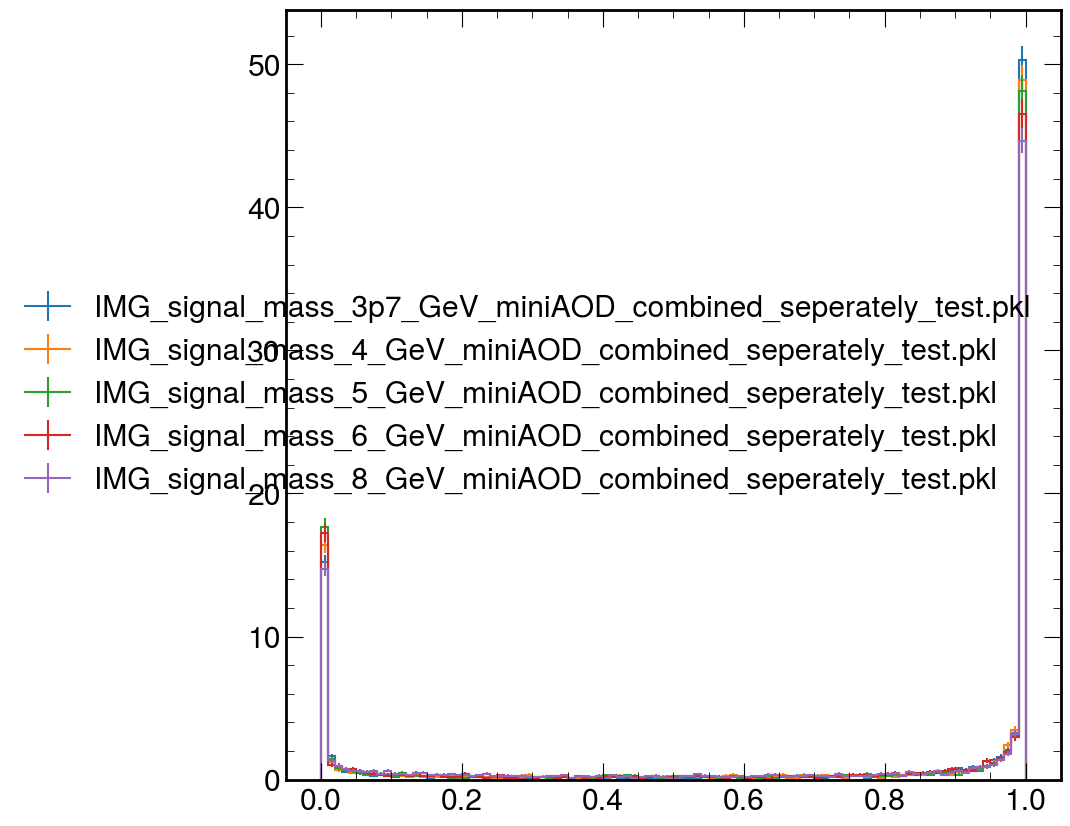

In [7]:
colors = plt.cm.tab10.colors  # or any colormap; gives 10 distinct colors
# colors = ['g', 'b', 'r', 'orange', 'purple', 'brown', 'k', 'cyan', 'magenta', 'gray']

# Initialize cumulative counters before the loop
total_jets_all = 0
total_below_all = 0
total_above_all = 0
total_selected_all = 0

for i, file_ in enumerate(data_files_signal):
    data_file = f"{data_dir}/{file_}"
    print(data_file)
    with open(data_file, "rb") as infile:
        data = pickle.load(infile)

    classifier_score = np.asarray(data["classifier_score"]).flatten()
    m_pred_total = corrected_pred_mode_miniAOD_5(data["m_pred"]).flatten()

    assert classifier_score.shape == m_pred_total.shape, (
        f"Shape mismatch: classifier_score {classifier_score.shape} "
        f"vs m_pred_total {m_pred_total.shape}"
    )

    n_below = np.sum(classifier_score < 0.5)
    n_above = np.sum(classifier_score >= 0.5)
    n_total = len(classifier_score)
    print(f"  Total jets: {n_total}")
    print(f"  Jets with score < 0.5: {n_below} ({n_below/n_total:.2%})")
    print(f"  Jets with score >= 0.5: {n_above} ({n_above/n_total:.2%})")

    mask = (classifier_score >= 0.5) & (m_pred_total >= 3.7) & (m_pred_total <= 14)
    m_pred_selected = m_pred_total[mask]
    n_selected = len(m_pred_selected)
    print(f"  Jets with score >= 0.5 and m_pred in [3.7, 14]: {n_selected} "
          f"({n_selected/n_total:.2%} of total)")
    print("||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||")
    # --- Final totals across all files ---
    # --- Accumulate totals ---
    total_jets_all += n_total
    total_below_all += n_below
    total_above_all += n_above
    total_selected_all += n_selected

    bins = np.arange(0, 1.01, .01)
    h1_counts, h1_bins = np.histogram(classifier_score, bins=bins)
    hep.histplot(
        h1_counts, h1_bins,
        histtype='step', yerr=True,
        label=file_,
        linestyle='-',
        color=colors[i % len(colors)],
        density=True
    )

plt.legend()

print("\n=== TOTALS ACROSS ALL FILES ===")
print(f"Total jets: {total_jets_all}")
print(f"Jets with score < 0.5: {total_below_all} ({total_below_all/total_jets_all:.2%})")
print(f"Jets with score >= 0.5: {total_above_all} ({total_above_all/total_jets_all:.2%})")
print(f"Jets with score >= 0.5 and m_pred in [3.7, 14]: {total_selected_all} "
        f"({total_selected_all/total_jets_all:.2%} of total)")


../analysis_run3/Data_for_plots/classifier_and_mass_regression_5_ch_inference_miniAOD_June_15_2026/IMG_background_HTo2Tau_miniAOD_combined_seperately_test.pkl
  Total events: 23350
  Events passing classifier (both jets >= 0.5): 3840 (16.45%)
  Events passing classifier AND mass window [3.7,14] (both jets): 2029 (8.69% of total)
  Events passing classifier AND mass window AND SR (|Δm| <= 2): 741 (3.17% of total)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
../analysis_run3/Data_for_plots/classifier_and_mass_regression_5_ch_inference_miniAOD_June_15_2026/IMG_background_TTbar_miniAOD_combined_seperately_test.pkl
  Total events: 50033
  Events passing classifier (both jets >= 0.5): 8683 (17.35%)
  Events passing classifier AND mass window [3.7,14] (both jets): 4009 (8.01% of total)
  Events passing classifier AND mass window AND SR (|Δm| <= 2): 1666 (3.33% of total)
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||

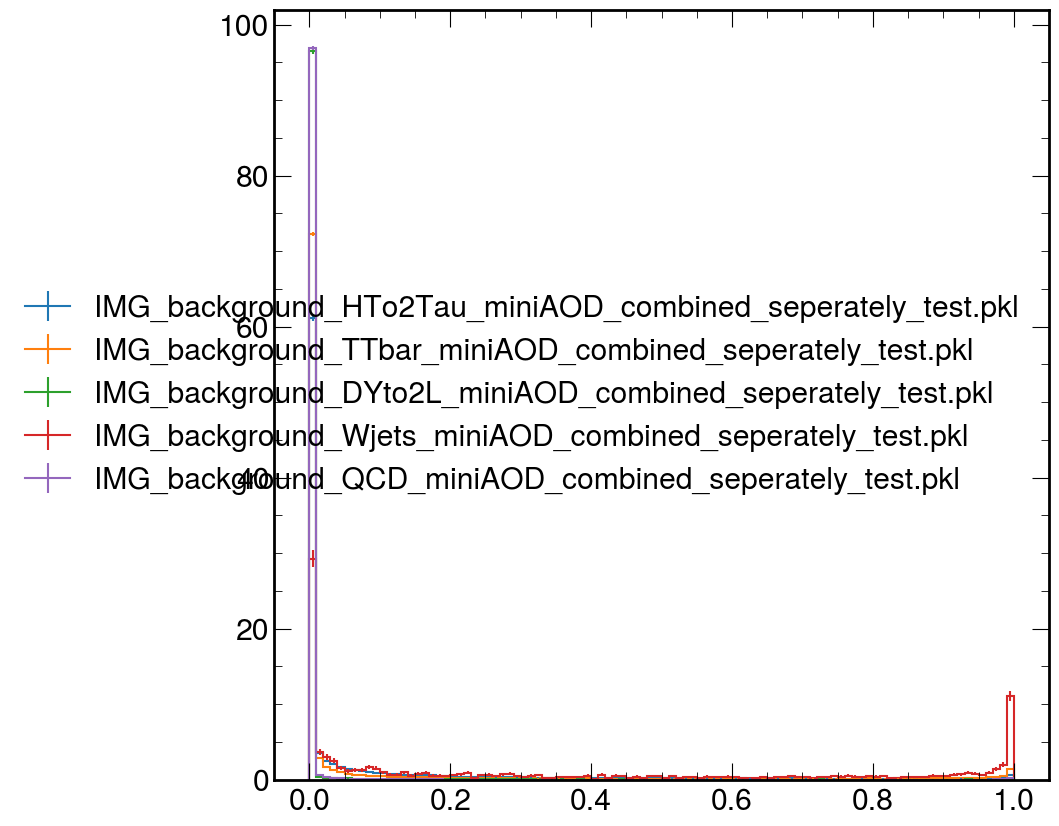

In [8]:
colors = plt.cm.tab10.colors

# Initialize cumulative counters before the loop
total_events_all = 0
total_pass_classifier_all = 0
total_pass_mass_all = 0
total_pass_sr_all = 0

for i, file_ in enumerate(data_files_back):
    data_file = f"{data_dir}/{file_}"
    print(data_file)
    with open(data_file, "rb") as infile:
        data = pickle.load(infile)

    classifier_score_total = np.asarray(data["classifier_score"]).flatten()
    m_pred_total = corrected_pred_mode_miniAOD_5(data["m_pred"]).flatten()

    assert classifier_score_total.shape == m_pred_total.shape, (
        f"Shape mismatch: classifier_score {classifier_score_total.shape} "
        f"vs m_pred_total {m_pred_total.shape}"
    )

    # ---------------------------------------------------------
    # Reshape into event pairs (2 jets per event)
    # ---------------------------------------------------------
    n = len(m_pred_total)
    n_even = n  # assumes even; add n - (n % 2) trimming if needed

    classifier_score = classifier_score_total[:n_even].reshape(-1, 2)
    m_pred = m_pred_total[:n_even].reshape(-1, 2)

    n_events_total = len(classifier_score)

    # ---------------------------------------------------------
    # Step 1: classifier cut FIRST — both jets must pass
    # ---------------------------------------------------------
    class_mask = (classifier_score[:, 0] >= 0.5) | (classifier_score[:, 1] >= 0.5)
    n_pass_classifier = class_mask.sum()

    m_pred_passed = m_pred[class_mask]

    print(f"  Total events: {n_events_total}")
    print(f"  Events passing classifier (both jets >= 0.5): {n_pass_classifier} "
          f"({n_pass_classifier/n_events_total:.2%})")

    # ---------------------------------------------------------
    # Step 2: mass window — both jets must be in [3.7, 14]
    # (applied only to events that already passed classifier cut)
    # ---------------------------------------------------------
    mass_mask = (
        (m_pred_passed[:, 0] >= 3.7) & (m_pred_passed[:, 0] <= 14) &
        (m_pred_passed[:, 1] >= 3.7) & (m_pred_passed[:, 1] <= 14)
    )
    n_pass_mass = mass_mask.sum()

    m_pred_mass_passed = m_pred_passed[mass_mask]

    print(f"  Events passing classifier AND mass window [3.7,14] (both jets): "
          f"{n_pass_mass} ({n_pass_mass/n_events_total:.2%} of total)")

    # ---------------------------------------------------------
    # Step 3: Signal Region (SR) — |m_jet1 - m_jet2| <= 2
    # (applied only to events that already passed classifier + mass cuts)
    # ---------------------------------------------------------
    sr_mask = np.abs(m_pred_mass_passed[:, 0] - m_pred_mass_passed[:, 1]) <= 2
    n_pass_sr = sr_mask.sum()

    print(f"  Events passing classifier AND mass window AND SR (|Δm| <= 2): "
          f"{n_pass_sr} ({n_pass_sr/n_events_total:.2%} of total)")
    print("||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||")

    # --- Accumulate totals ---
    total_events_all += n_events_total
    total_pass_classifier_all += n_pass_classifier
    total_pass_mass_all += n_pass_mass
    total_pass_sr_all += n_pass_sr

    # ---------------------------------------------------------
    # Plot classifier score distribution (flattened, both jets)
    # ---------------------------------------------------------
    bins = np.arange(0, 1.01, .01)
    h1_counts, h1_bins = np.histogram(classifier_score_total[:n_even], bins=bins)
    hep.histplot(
        h1_counts, h1_bins,
        histtype='step', yerr=True,
        label=file_,
        linestyle='-',
        color=colors[i % len(colors)],
        density=True
    )

plt.legend()

print("\n=== TOTALS ACROSS ALL FILES (EVENT-LEVEL) ===")
print(f"Total events: {total_events_all}")
print(f"Events passing classifier (both jets >= 0.5): {total_pass_classifier_all} "
      f"({total_pass_classifier_all/total_events_all:.2%})")
print(f"Events passing classifier AND mass window [3.7,14]: {total_pass_mass_all} "
      f"({total_pass_mass_all/total_events_all:.2%} of total)")
print(f"Events passing classifier AND mass window AND SR (|Δm| <= 2): {total_pass_sr_all} "
      f"({total_pass_sr_all/total_events_all:.2%} of total)")

In [6]:
m0_min=3.6
m0_max=14.1
bin_size =0.4
bins = np.arange(m0_min,m0_max,bin_size)
sig = ['3.7 GeV ', '4 GeV', '5 GeV', '6 GeV', '8 GeV', '10 GeV', '12 GeV', '14 GeV']
# back = ["DYto2L X 10^5", "HTo2Tau X 10^6", "QCD", "TTbar X 10^5", "Wjets X 10^4"]
back = ["HTo2Tau", "TTbar", "DYto2L", "Wjets", "QCD"]
col_ = ['blue','grey','red','orange', 'green']


total_background, total_weight = [], []
total_background_sr, total_weight_sr_total = [], []
total_background_sb, total_weight_sb_total = [], []
total_background_leading_sr, total_background_subleading_sr, total_weight_sr = [], [], []
total_background_leading_sb, total_background_subleading_sb, total_weight_sb = [], [], []

luminosity = 181000
cross_section = np.array([3.166e1, 7.623e2, 5.453e3, 6.808e4, 1.448e9])
total_gen_events = np.array([3e5, 3e5, 4e5, 2.35e5, 2.74e5])
W = cross_section * luminosity / total_gen_events

for i, file_ in enumerate(data_files_back):

    data_file = f"{data_dir}/{file_}"

    with open(data_file, "rb") as infile:
        data = pickle.load(infile)

    m_pred_total = corrected_pred_mode_miniAOD_5(data["m_pred"]).flatten()
    jet_pt_total = data["jet_pt"].flatten()
    classifier_score_total = np.asarray(data["classifier_score"]).flatten()

    # ---------------------------------------------------------
    # Make even number of jets
    # ---------------------------------------------------------
    n = len(m_pred_total)
    n_even = n  # - (n % 2)

    # reshape into jet pairs (events)
    m_pred = m_pred_total[:n_even].reshape(-1, 2)
    jet_pt = jet_pt_total[:n_even].reshape(-1, 2)
    classifier_score = classifier_score_total[:n_even].reshape(-1, 2)

    # ---------------------------------------------------------
    # NEW: Event-level classifier selection
    # BOTH jets must have classifier_score >= 0.5
    # ---------------------------------------------------------
    class_mask = (classifier_score[:, 0] >= 0.5) | (classifier_score[:, 1] >= 0.5)

    m_pred = m_pred[class_mask]
    jet_pt = jet_pt[class_mask]

    # ---------------------------------------------------------
    # Leading / subleading jet indices
    # ---------------------------------------------------------
    lead_idx = np.argmax(jet_pt, axis=1)
    sublead_idx = 1 - lead_idx

    m_leading = m_pred[np.arange(len(m_pred)), lead_idx]
    m_subleading = m_pred[np.arange(len(m_pred)), sublead_idx]

    pt_leading = jet_pt[np.arange(len(jet_pt)), lead_idx]
    pt_subleading = jet_pt[np.arange(len(jet_pt)), sublead_idx]

    # ---------------------------------------------------------
    # Event-level mass selection:
    # BOTH jets must satisfy the mass window
    # ---------------------------------------------------------
    mask_pair = (
        (m_leading >= 3.6) &
        (m_leading <= 14) &
        (m_subleading >= 3.6) &
        (m_subleading <= 14)
    )

    m_leading = m_leading[mask_pair]
    m_subleading = m_subleading[mask_pair]
    print("Sample-------------------------------", file_)
    print("len(m_leading)-----------------------", len(m_leading))
    # ---------------------------------------------------------
    # Save total selected jets
    # ---------------------------------------------------------
    total_background.append(np.concatenate([m_leading, m_subleading]))
    weights = np.ones(len(m_leading) * 2) * W[i]
    total_weight.append(weights)

    # ---------------------------------------------------------
    # Signal region
    # ---------------------------------------------------------
    sr_mask = np.abs(m_leading - m_subleading) <= 2

    m_leading_sr = m_leading[sr_mask]
    m_subleading_sr = m_subleading[sr_mask]
    weights_sr = np.ones_like(m_leading_sr) * W[i]

    total_background_leading_sr.append(m_leading_sr)
    total_background_subleading_sr.append(m_subleading_sr)
    total_weight_sr.append(weights_sr)

    total_background_sr.append(np.concatenate([m_leading_sr, m_subleading_sr]))
    weights_sr_total = np.ones(len(m_leading_sr) * 2) * W[i]
    total_weight_sr_total.append(weights_sr_total)

    # ---------------------------------------------------------
    # Sideband region
    # ---------------------------------------------------------
    sb_mask = np.abs(m_leading - m_subleading) > 2

    m_leading_sb = m_leading[sb_mask]
    m_subleading_sb = m_subleading[sb_mask]
    weights_sb = np.ones_like(m_leading_sb) * W[i]

    total_background_leading_sb.append(m_leading_sb)
    total_background_subleading_sb.append(m_subleading_sb)
    total_weight_sb.append(weights_sb)

    total_background_sb.append(np.concatenate([m_leading_sb, m_subleading_sb]))
    weights_sb_total = np.ones(len(m_leading_sb) * 2) * W[i]
    total_weight_sb_total.append(weights_sb_total)


dpi_=100
save = False
# =========================================================
# Stack histogram
# =========================================================

fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background,
    bins=bins,
    weights=total_weight,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,
)
# plt.yscale('log')
# plt.ylim(1, 1e13)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')

plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f" ROI                     13.6 TeV", loc=0, ax=ax)
ax = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_ROI_normalized_classifier_in_or_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")


fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_sr,
    bins=bins,
    weights=total_weight_sr_total,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,
)

plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')

plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f" SR                     13.6 TeV", loc=0, ax=ax)
x = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_SR_normalized_classifier_in_or_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")


fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_sb,
    bins=bins,
    weights=total_weight_sb_total,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,
)

plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')
plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f" SB                     13.6 TeV", loc=0, ax=ax)
x = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_SB_normalized_classifier_in_or_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")




fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_leading_sr,
    bins=bins,
    weights=total_weight_sr,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,
)
# plt.ylim(0,3000)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')

plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f"     Leading SR               13.6 TeV", loc=0, ax=ax)
x = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_leading_SR_normalized_classifier_in_or_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")


fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_subleading_sr,
    bins=bins,
    weights=total_weight_sr,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,
)
# plt.ylim(0,3000)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')

plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f"        Subleading SR            13.6 TeV", loc=0, ax=ax)
x = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_subleading_SR_normalized_classifier_in_or_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")




fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_leading_sb,
    bins=bins,
    weights=total_weight_sb,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,

)
# plt.ylim(0,3500)
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')

plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f"     Leading SB               13.6 TeV", loc=0, ax=ax)
x = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_leading_SB_normalized_classifier_in_or_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")


fig, ax = plt.subplots(dpi=dpi_)
plt.hist(
    total_background_subleading_sb,
    bins=bins,
    weights=total_weight_sb,
    stacked=True,
    histtype="barstacked",
    color=col_,
    label=back,
    log=1,
    edgecolor='none',
    linewidth=0,
    antialiased=False,
    rasterized=True,
)
# plt.ylim(1,1e13)
# plt.yscale('log')
plt.xlabel(r'$m_{A, pred}$ [GeV]')
plt.ylabel('Events/ 0.4 [GeV]')

plt.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=0.5
)
hep.cms.label(llabel="Simulation", rlabel=f"        Subleading SB            13.6 TeV", loc=0, ax=ax)
x = plt.gca()
offset = ax.yaxis.get_offset_text()
offset.set_x(-0.06)   # left/right
offset.set_y(1.02)    # up/down
if save: plt.savefig(f'{out_dir}/stack_plot_for_total_backgrounds_subleading_SB_normalized_classifier_in_or_log.pdf', bbox_inches='tight',dpi=300, facecolor = "w")

NameError: name 'data_files_back' is not defined

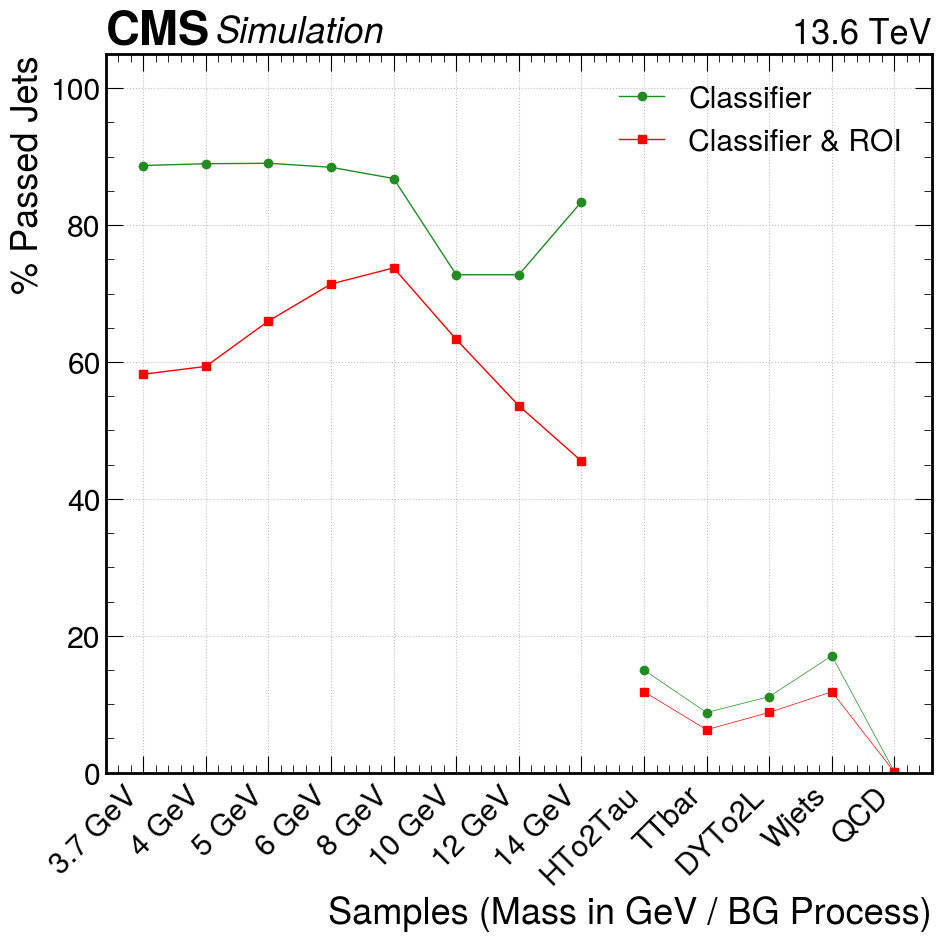

In [3]:
out_dir='../analysis_run3/AN_Note_Plot/stack_plots_after_classifier'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)
# --- Data Extraction ---
# Signal Mass Points (GeV) followed by background names
signal_mass = np.array([3.7, 4, 5, 6, 8, 10, 12, 14, 'HTo2Tau', 'TTbar', 'DYTo2L', 'Wjets', 'QCD'])

# Signal and Background Efficiencies (%)
sig_pass_05 = np.array([88.71, 88.97, 89.04, 88.45, 86.81, 72.75, 72.75, 83.41, 14.99, 8.79, 11.12, 17.08, 0.13])
sig_pass_roi = np.array([58.21, 59.36, 65.99, 71.40, 73.75, 63.30, 53.61, 45.53, 11.83, 6.28, 8.81, 11.83, 0.08])

dpi_ = 100
save = False

# --- Plotting ---
fig, ax = plt.subplots(dpi=dpi_)

# 1. Plot Signal Only (Indices 0 to 7)
plt.plot(signal_mass[:8], sig_pass_05[:8], marker='o', color='forestgreen', linewidth=1, rasterized=True, label='Classifier')
plt.plot(signal_mass[:8], sig_pass_roi[:8], marker='s', color='red', linewidth=1, rasterized=True, label='Classifier & ROI')

# 2. Plot Background Only (Indices 8 onwards) - disconnected from signal, no labels to avoid legend duplication
plt.plot(signal_mass[8:], sig_pass_05[8:], marker='o', color='forestgreen', linewidth=0.5, rasterized=True)
plt.plot(signal_mass[8:], sig_pass_roi[8:], marker='s', color='red', linewidth=0.5, rasterized=True)

plt.ylabel('% Passed Jets')
plt.xlabel('Samples (Mass in GeV / BG Process)')
plt.legend(loc='upper right')
plt.grid()
plt.ylim(0, 105)

# Format x-axis labels correctly even when typecast as strings by numpy
all_ticks = list(signal_mass)
plt.xticks(range(len(all_ticks)))


def format_label(m):
    try:
        float(m)
        return f"{m} GeV"
    except ValueError:
        return m


ax.set_xticklabels([format_label(m) for m in all_ticks], rotation=45, ha='right')

hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()

if save: 
    plt.savefig(f'{out_dir}/signal_background_classifier_roi_efficiency_jet_level.pdf', bbox_inches='tight', dpi=200, facecolor="w")

plt.show()

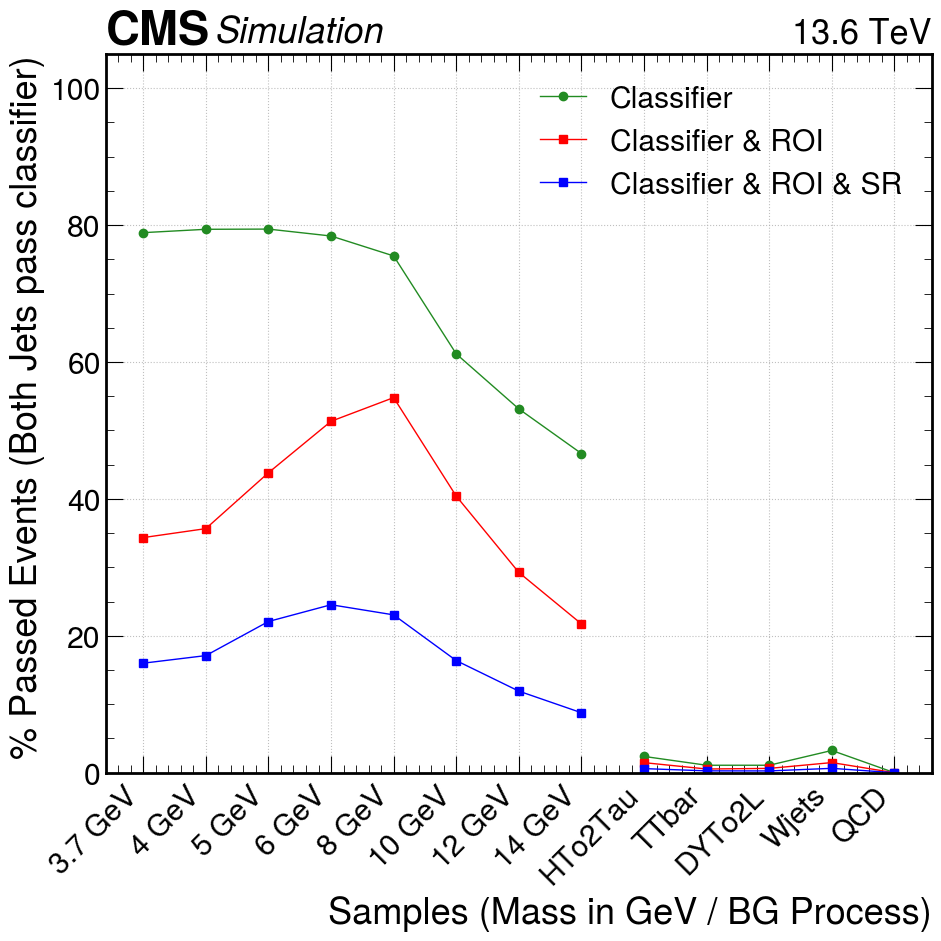

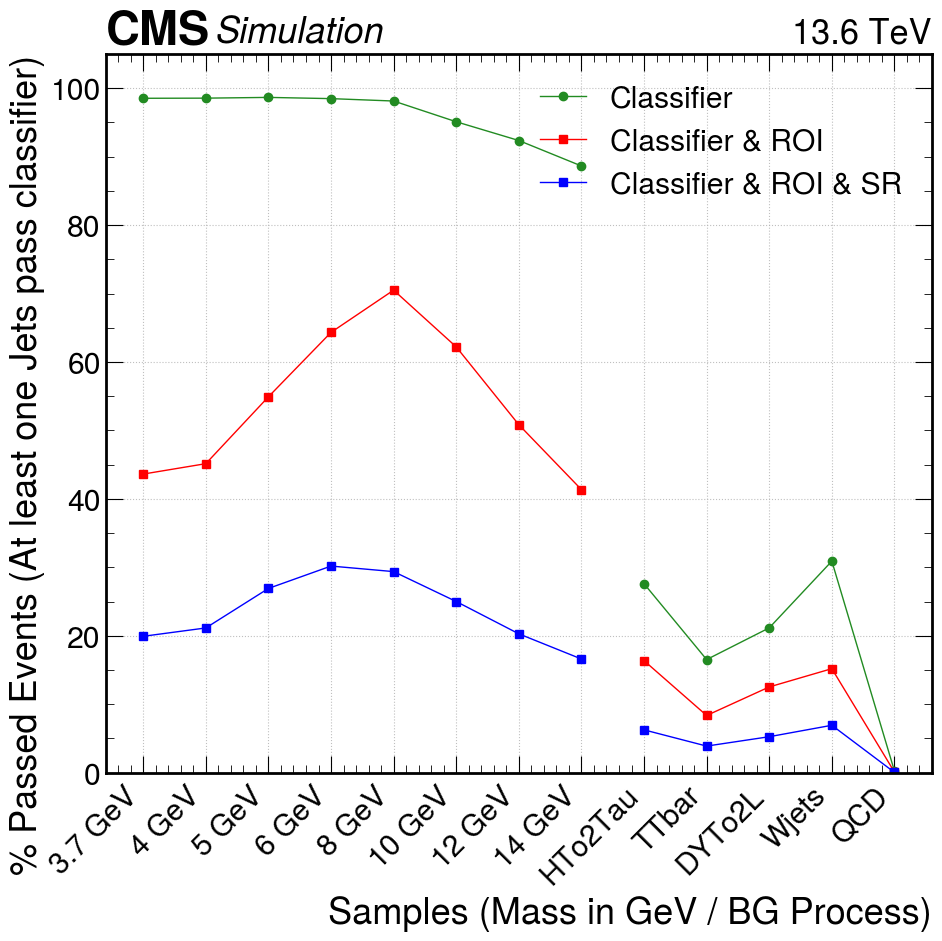

In [10]:
signal_mass = np.array([3.7, 4, 5, 6, 8, 10, 12, 14,
                        'HTo2Tau', 'TTbar', 'DYTo2L', 'Wjets', 'QCD'])

# Both jets >= 0.5
bothjet_05 = np.array([
    78.90, 79.39, 79.42, 78.41, 75.50, 61.19, 53.15, 46.63,
    2.38, 1.09, 1.09, 3.25, 0.00
])

# Classifier (both jets) ∩ ROI
bothjet_roi = np.array([
    34.35, 35.66, 43.82, 51.34, 54.80, 40.41, 29.26, 21.74,
    1.47, 0.54, 0.63, 1.48, 0.00
])

# Classifier ∩ ROI ∩ SR
bothjet_roi_sr = np.array([
    16.00, 17.11, 22.09, 24.54, 23.06, 16.38, 11.92, 8.76,
    0.60, 0.27, 0.26, 0.64, 0.00
])

# At least 1 jet >= 0.5
onejet_05 = np.array([
    98.53, 98.55, 98.66, 98.48, 98.13, 95.10, 92.36, 88.64,
    27.61, 16.53, 21.16, 30.91, 0.25
])

# Classifier (at least 1 jet) ∩ ROI
onejet_roi = np.array([
    43.63, 45.15, 54.92, 64.33, 70.50, 62.21, 50.84, 41.36,
    16.37, 8.36, 12.53, 15.20, 0.10
])

# Classifier ∩ ROI ∩ SR
onejet_roi_sr = np.array([
    19.93, 21.15, 26.92, 30.19, 29.38, 25.01, 20.29, 16.61,
    6.26, 3.89, 5.26, 6.93, 0.05
])


dpi_ = 100
save = False

# --- Plotting ---
fig, ax = plt.subplots(dpi=dpi_)

# 1. Plot Signal Only (Indices 0 to 7)
plt.plot(signal_mass[:8], bothjet_05[:8], marker='o', color='forestgreen', linewidth=1, rasterized=True, label='Classifier')
plt.plot(signal_mass[:8], bothjet_roi[:8], marker='s', color='red', linewidth=1, rasterized=True, label='Classifier & ROI')
plt.plot(signal_mass[:8], bothjet_roi_sr[:8], marker='s', color='blue', linewidth=1, rasterized=True, label='Classifier & ROI & SR')

# 2. Plot Background Only (Indices 8 onwards) - disconnected from signal, no labels to avoid legend duplication
plt.plot(signal_mass[8:], bothjet_05[8:], marker='o', color='forestgreen', linewidth=1, rasterized=True)
plt.plot(signal_mass[8:], bothjet_roi[8:], marker='s', color='red', linewidth=1, rasterized=True)
plt.plot(signal_mass[8:], bothjet_roi_sr[8:], marker='s', color='blue', linewidth=1, rasterized=True)

plt.ylabel('% Passed Events (Both Jets pass classifier)')
plt.xlabel('Samples (Mass in GeV / BG Process)')
plt.legend(loc='upper right')
plt.grid()
plt.ylim(0, 105)

# Format x-axis labels correctly even when typecast as strings by numpy
all_ticks = list(signal_mass)
plt.xticks(range(len(all_ticks)))


def format_label(m):
    try:
        float(m)
        return f"{m} GeV"
    except ValueError:
        return m


ax.set_xticklabels([format_label(m) for m in all_ticks], rotation=45, ha='right')

hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()

if save: 
    plt.savefig(f'{out_dir}/signal_background_classifier_both_jet_pass_efficiency_event_level.pdf', bbox_inches='tight', dpi=200, facecolor="w")

plt.show()





# --- Plotting ---
fig, ax = plt.subplots(dpi=dpi_)

# 1. Plot Signal Only (Indices 0 to 7)
plt.plot(signal_mass[:8], onejet_05[:8], marker='o', color='forestgreen', linewidth=1, rasterized=True, label='Classifier')
plt.plot(signal_mass[:8], onejet_roi[:8], marker='s', color='red', linewidth=1, rasterized=True, label='Classifier & ROI')
plt.plot(signal_mass[:8], onejet_roi_sr[:8], marker='s', color='blue', linewidth=1, rasterized=True, label='Classifier & ROI & SR')

# 2. Plot Background Only (Indices 8 onwards) - disconnected from signal, no labels to avoid legend duplication
plt.plot(signal_mass[8:], onejet_05[8:], marker='o', color='forestgreen', linewidth=1, rasterized=True)
plt.plot(signal_mass[8:], onejet_roi[8:], marker='s', color='red', linewidth=1, rasterized=True)
plt.plot(signal_mass[8:], onejet_roi_sr[8:], marker='s', color='blue', linewidth=1, rasterized=True)

plt.ylabel('% Passed Events (At least one Jets pass classifier)')
plt.xlabel('Samples (Mass in GeV / BG Process)')
plt.legend(loc='upper right')
plt.grid()
plt.ylim(0, 105)

# Format x-axis labels correctly even when typecast as strings by numpy
all_ticks = list(signal_mass)
plt.xticks(range(len(all_ticks)))


def format_label(m):
    try:
        float(m)
        return f"{m} GeV"
    except ValueError:
        return m


ax.set_xticklabels([format_label(m) for m in all_ticks], rotation=45, ha='right')

hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()

if save: 
    plt.savefig(f'{out_dir}/signal_background_classifier_atleat_one_jet_pass_efficiency_event_level.pdf', bbox_inches='tight', dpi=200, facecolor="w")

plt.show()